In [24]:
from sklearn.datasets import fetch_openml

X, y = fetch_openml('fashion-mnist', version=1, return_X_y=True, as_frame=False)

In [25]:
X.shape, y.shape

((70000, 784), (70000,))

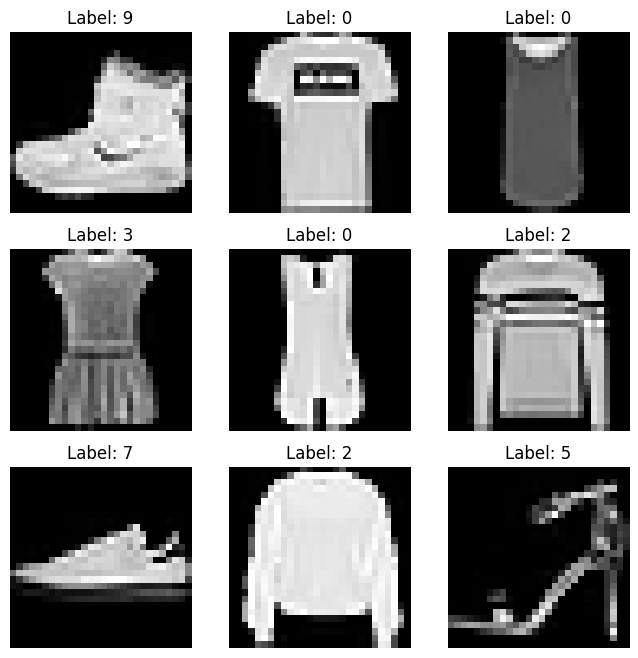

In [27]:
import matplotlib.pyplot as plt
import numpy as np

# Tasodifiy 9 ta rasmni ko‘rsatamiz
plt.figure(figsize=(8, 8))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(X[i].reshape(28, 28), cmap='gray')  # 784 → 28x28
    plt.title(f"Label: {y[i]}")
    plt.axis('off')
plt.show()


In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((56000, 784), (14000, 784), (56000,), (14000,))

In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [11]:
from sklearn.neural_network import MLPClassifier

mlp_clf = MLPClassifier(hidden_layer_sizes=10, activation='relu', random_state=42)
mlp_clf.fit(X_train, y_train)

c:\Users\Mezon\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPClassifier(hidden_layer_sizes=10, random_state=42)

In [12]:
mlp_clf.score(X_test, y_test)

0.8525

In [13]:
mlp_clf.score(X_train, y_train)

0.9043035714285714

In [14]:
import joblib

In [15]:
joblib.dump(mlp_clf, 'fashion_mnist_mlp_model.joblib')

['fashion_mnist_mlp_model.joblib']

In [18]:
from sklearn.model_selection import GridSearchCV

cv = GridSearchCV(
    MLPClassifier(random_state=42),
    param_grid={
        'hidden_layer_sizes': [(10,), (50,)],
        'activation': ['relu', 'tanh'],
        "learning_rate_init": [0.001, 0.01]
    },
    n_jobs=-1
)

In [20]:
best_model = MLPClassifier(hidden_layer_sizes=50, activation='relu', learning_rate_init=0.001, random_state=42)

In [21]:
best_model.fit(X_train, y_train)

MLPClassifier(hidden_layer_sizes=50, random_state=42)

In [22]:
best_model.score(X_test, y_test), best_model.score(X_train, y_train)

(0.8774285714285714, 0.997)

In [23]:
joblib.dump(best_model, 'fashion_mnist_mlp_model_best.joblib')

['fashion_mnist_mlp_model_best.joblib']